In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

# Construct the full path to the CSV file
file_path = os.path.join(path, 'xAPI-Edu-Data.csv')

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

  gender NationalITy PlaceofBirth     StageID GradeID SectionID Topic  \
0      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
1      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
2      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
3      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
4      M          KW       KuwaIT  lowerlevel    G-04         A    IT   

  Semester Relation  raisedhands  VisITedResources  AnnouncementsView  \
0        F   Father           15                16                  2   
1        F   Father           20                20                  3   
2        F   Father           10                 7                  0   
3        F   Father           30                25                  5   
4        F   Father           40                50                 12   

   Discussion ParentAnsweringSurvey ParentschoolSatisfaction  \
0          20                   Yes                     Go

In [4]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [6]:
# EDA
# checking null values
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [7]:
# VISUALIZATION

### Distribution of the Target Variable ('Class')

Let's examine the distribution of the 'Class' variable. This will help us understand the proportion of students in each performance category (Low, Middle, High) and identify any potential class imbalance, which is important for classification tasks.

/tmp/ipykernel_2890/2799063242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


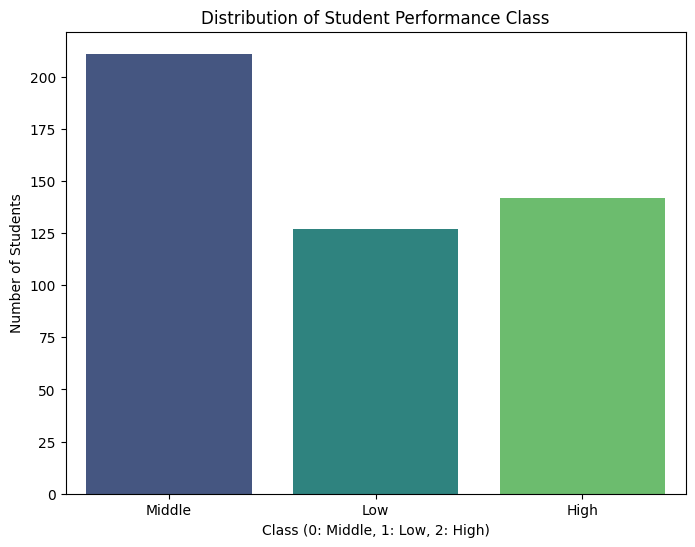

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Student Performance Class')
plt.xlabel('Class (0: Middle, 1: Low, 2: High)')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1, 2], labels=['Middle', 'Low', 'High'])
plt.show()

### Relationship between Gender and Class

Now, let's explore how the 'gender' of students is distributed across the different 'Class' categories. This visualization can highlight if there's any noticeable difference in performance between male and female students.

/tmp/ipykernel_2890/1872957575.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gen_class = df_plot.groupby(['Class_Label'])[['gender_F', 'gender_M']].sum().reset_index()


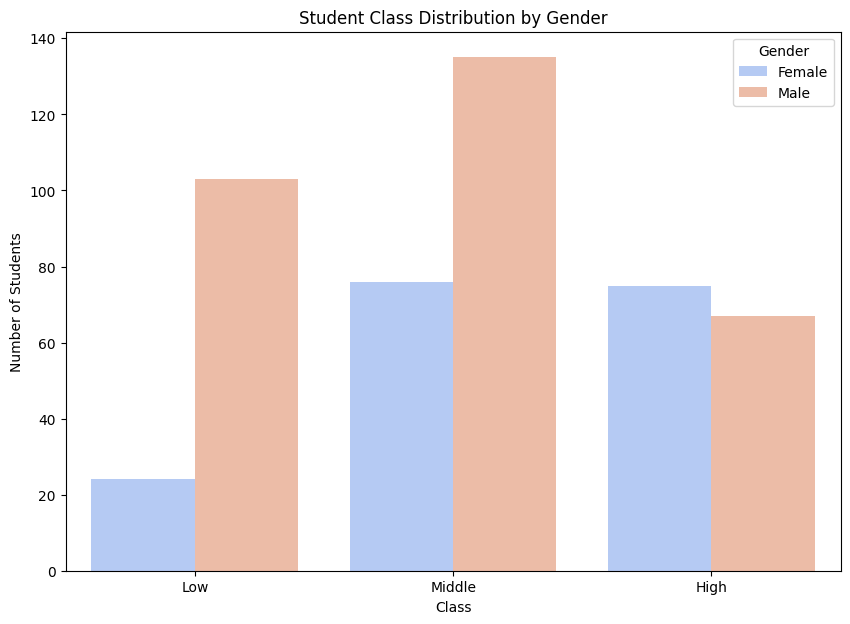

In [10]:
df_plot = df.copy()
df_plot['Class_Label'] = df_plot['Class'].map({'M': 'Middle', 'L': 'Low', 'H': 'High'})

# Check if 'gender' column exists (meaning it hasn't been one-hot encoded yet)
if 'gender' in df_plot.columns:
    # Perform one-hot encoding
    df_plot = pd.get_dummies(df_plot, columns=['gender'], drop_first=False)


category_order = ['Low', 'Middle', 'High'] # Define desired order
if 'Class_Label' in df_plot.columns:
    df_plot['Class_Label'] = pd.Categorical(df_plot['Class_Label'], categories=category_order, ordered=True)

gen_class = df_plot.groupby(['Class_Label'])[['gender_F', 'gender_M']].sum().reset_index()
gen_class_melted = gen_class.melt(id_vars='Class_Label', var_name='Gender', value_name='Count')
gen_class_melted['Gender'] = gen_class_melted['Gender'].replace({'gender_F': 'Female', 'gender_M': 'Male'})

plt.figure(figsize=(10, 7))
sns.barplot(x='Class_Label', y='Count', hue='Gender', data=gen_class_melted, palette='coolwarm')
plt.title('Student Class Distribution by Gender')
plt.xlabel('Class')
plt.ylabel('Number of Students')
plt.show()

### Relationship between 'Raised Hands' and Class

This visualization will show the distribution of 'raisedhands' for each 'Class' category. It can indicate if students who raise their hands more frequently tend to fall into a particular performance class.

/tmp/ipykernel_2890/2439826191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='raisedhands', data=df, palette='viridis')


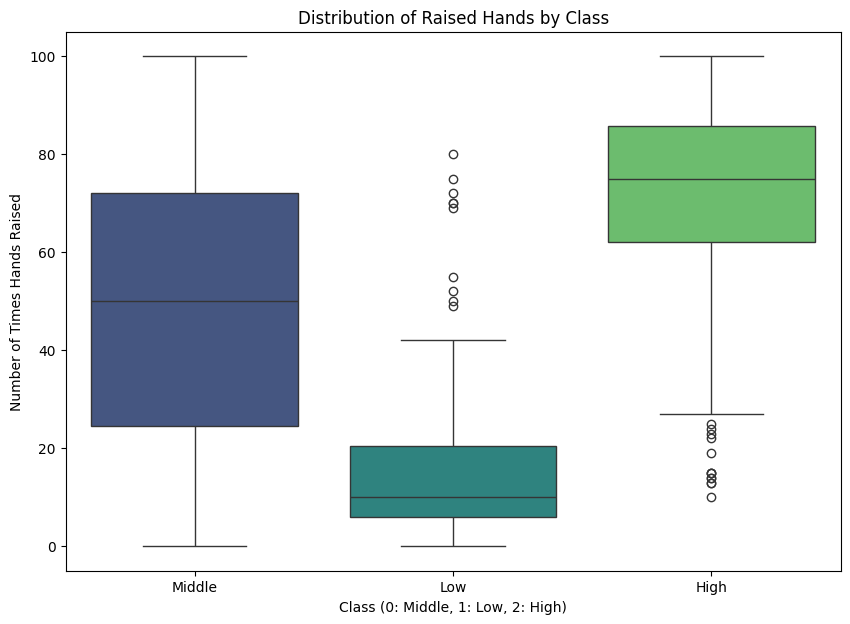

In [11]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Class', y='raisedhands', data=df, palette='viridis')
plt.title('Distribution of Raised Hands by Class')
plt.xlabel('Class (0: Middle, 1: Low, 2: High)')
plt.ylabel('Number of Times Hands Raised')
plt.xticks(ticks=[0, 1, 2], labels=['Middle', 'Low', 'High'])
plt.show()

### Relationship between 'Topic' and Class

Here, we'll look at the distribution of student performance 'Class' across different 'Topic's. This might reveal if certain subjects correlate with higher or lower student performance.

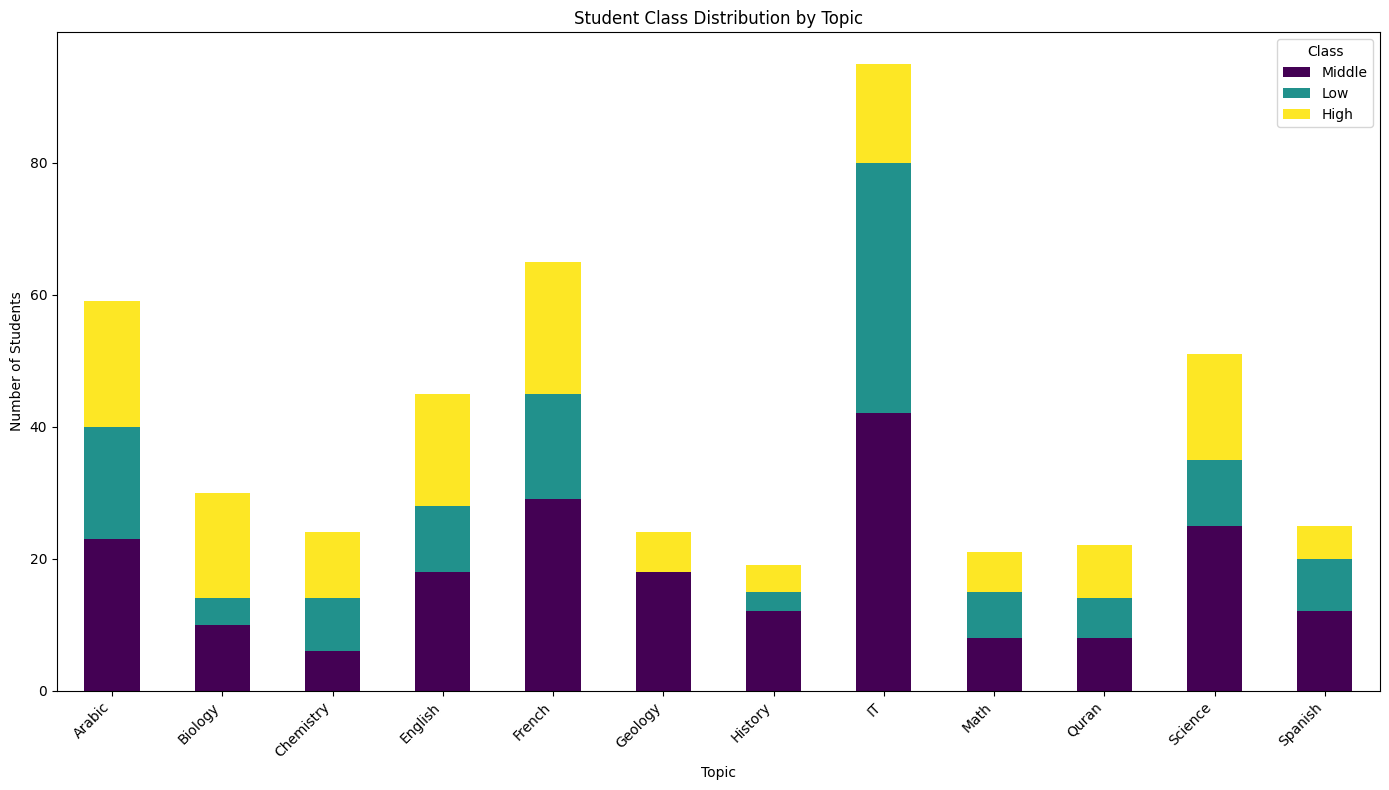

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the original dataframe for this specific visualization to access the 'Topic' column
# 'file_path' is available in the kernel state from a previous cell.
temp_df = pd.read_csv(file_path)

# Map the 'Class' column in this temporary dataframe for consistent labels (M:0, L:1, H:2)
temp_df["Class_mapped"] = temp_df["Class"].map({"M":0,"L":1,"H":2})

# Now perform the groupby using the original 'Topic' and the mapped 'Class'
topic_class = temp_df.groupby(['Topic', 'Class_mapped']).size().unstack(fill_value=0)

# Ensure columns are in the correct order (Middle, Low, High) and convert numerical labels back to meaningful labels for plotting
# Assuming 0: Middle, 1: Low, 2: High as per previous context
if 0 in topic_class.columns and 1 in topic_class.columns and 2 in topic_class.columns:
    topic_class = topic_class[[0, 1, 2]] # Order columns explicitly
topic_class.columns = topic_class.columns.map({0: 'Middle', 1: 'Low', 2: 'High'})

topic_class.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Student Class Distribution by Topic')
plt.xlabel('Topic')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

In [15]:
df.head(5)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [16]:
# ENCODING ALL THE OBJECT TYPES COLUMNS
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Exclude 'Class' from one-hot encoding as it will be mapped separately
if 'Class' in cat_cols:
    cat_cols.remove('Class')

df = pd.get_dummies(df, columns=cat_cols)

# Map the 'Class' column with correct syntax
df["Class"] = df["Class"].map({"M":0,"L":1,"H":2})


In [ ]:
# Data type ? ---> classification
# classification -----> class imbalance


In [17]:
# MODEL READING
#1.KNN CLASSIFICATION--> distance based algo so we will perform standard scaling

In [18]:
# Lets now split X and y variables
X = df.drop("Class",axis=1)
y = df["Class"]

In [19]:
# standardscaling --> to avoid data leakage
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.20 , random_state=42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [23]:
score = []
train_score = [] # Initialize train_score list
for k in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=k) # Corrected class name and parameter
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)

  accuracy = accuracy_score(y_test,y_pred)   # testing accuracy
  train = accuracy_score(y_train,knn.predict(X_train)) # training accuracy

  train_score.append(train)
  score.append(accuracy)

In [25]:
model = KNeighborsClassifier() # Corrected class name
model.fit(X_train,y_train)        # training KNN model

KNeighborsClassifier()

In [26]:
y_predict = model.predict(X_test)

In [27]:
# testing accuracy
accuracy_score(y_test,y_predict)

0.5729166666666666

In [29]:
# training accuracy
accuracy_score(y_train,model.predict(X_train))

0.7369791666666666

<Axes: >

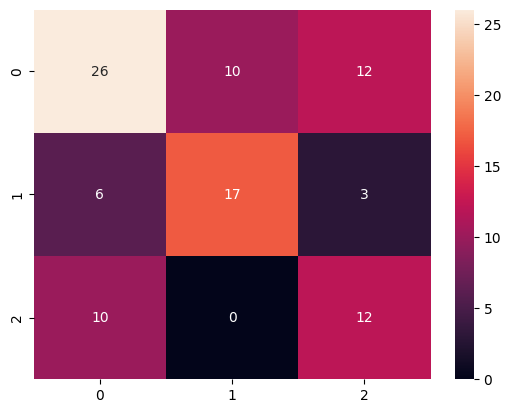

In [30]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_predict ),annot=True)